# Notebook16 – RL-Guided Rollout Evaluation inside the CHO Digital Twin

---

# Why Notebook16 Exists

Notebook14v2 created a dynamic CHO digital twin.

For the first time in the project, clone behavior was represented as:

state → action → reward → transition → trajectory

instead of static clone rankings.

This allowed virtual CHO clones to evolve through pseudo-time while responding to process interventions.

---

# What Notebook15 Added

Notebook15 transformed these trajectories into a reinforcement-learning environment.

The notebook:

- discretized cellular states
- constructed offline transitions
- calculated long-term state values
- learned optimal actions using Q-learning

As a result, Notebook15 generated:

```text
RL State
     ↓
Best Action
     ↓
Expected Long-Term Value
```

for hundreds of cellular conditions.

However, Notebook15 only learned from historical trajectories.

The learned policy was never allowed to actively control the simulator.

Therefore an important question remains:

```text
Can the learned policy improve future clone trajectories?
```

Notebook16 answers this question.

---

# Core Concept

A learned policy is only useful if it performs better than existing decision-making strategies.

Therefore Notebook16 compares three controllers:

### 1. RL Controller

Uses:

RL State
→ Learned Best Action

from Notebook15.

The controller chooses actions according to the learned policy table.

---

### 2. Rule-Based Controller

Uses predefined biological rules.

Examples:

- high burden → perfusion rescue
- high risk → stress mitigation
- healthy culture → adaptive feed

This mimics traditional process-development decision making.

---

### 3. No-Action Controller

Applies no intervention.

This serves as the baseline condition.

---

# Digital Twin Rollout

Each controller receives identical starting cellular states.

The simulator then propagates each clone through pseudo-time:

```text
Current State
        ↓
Choose Action
        ↓
State Transition
        ↓
Reward
        ↓
Next State
```

This process repeats for multiple future time steps.

The result is a virtual process trajectory.

---

# Questions Addressed

Notebook16 asks:

### Productivity

Can RL maintain or improve productivity?

### Process Burden

Can RL reduce metabolic and stress burden?

### Product Quality

Can RL improve glycosylation quality?

### Risk

Can RL reduce cellular failure risk?

### Overall Process Performance

Can RL generate higher cumulative reward?

---

# Why This Notebook Matters

Notebook16 is the first notebook where:

```text
AI actively controls the digital twin.
```

Previous notebooks:

- predicted outcomes
- ranked clones
- simulated interventions
- learned policies

Notebook16 executes those policies.

This is the transition from:

Prediction

to

Decision-Making.

---

# Relation to SDL

This notebook represents the first operational step toward a true Self-Driving Laboratory (SDL).

Future SDL loop:

Measure State
        ↓
Infer Cellular Condition
        ↓
Select Optimal Action
        ↓
Apply Process Intervention
        ↓
Observe New State
        ↓
Learn Again

This closed-loop cycle is the foundation of autonomous bioprocess optimization.

---

# Expected Outputs

Notebook16 will generate:

- RL rollout trajectories
- Rule-based rollout trajectories
- No-action rollout trajectories

and compare:

- cumulative reward
- productivity
- burden
- risk
- glycosylation quality

across controllers.

The best-performing controller becomes the preferred decision engine for the digital twin.

---

# Long-Term Vision

The long-term objective is:

```text
Clone Selection
        +
Process Optimization
        +
Multi-Omics Understanding
        +
Reinforcement Learning
        +
Digital Twin Simulation
```

to create an integrated CHO Cell Line Development platform capable of:

- early clone ranking
- process optimization
- process rescue
- host-cell engineering guidance
- autonomous experimental design

for future CDO/CDMO and biomanufacturing applications.

# Section 1 – Load RL trajectory outputs

Notebook16 starts from the trajectory dataset generated in Notebook15.

These trajectories already contain:

- RL states

- recommended RL actions

- cellular-state variables

- pseudo-time evolution

This becomes the starting environment for rollout simulation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]

trajectory = pd.read_csv(
    ROOT /
    "data" /
    "synthetic" /
    "digital_twin" /
    "notebook15_trajectory_with_rl_policy_5000_legacy.csv"
)

trajectory.shape

(8280, 28)

# Section 2 – Load Dynamic Trajectory Dataset

Notebook16 begins with the dynamic trajectory dataset generated in Notebook14v2 and enriched in Notebook15.

Each row represents a cellular state observed at a specific pseudo-time point under a particular intervention strategy.

The dataset contains:

- productivity state
- burden state
- quality state
- risk state
- intervention history

These trajectories serve as the starting environment for rollout evaluation.

The objective is to determine how different controllers influence future cellular behavior.

In [2]:
policy_df = pd.read_csv(
    ROOT /
    "data" /
    "synthetic" /
    "digital_twin" /
    "notebook15_rl_policy_5000_legacy.csv"
)

policy_df.head()

,rl_state,best_action,state_value
0,P0_B0_R0_G0_O0,no_action,8.485563
1,P0_B0_R0_G1_O0,perfusion_rescue,9.020984
2,P0_B0_R0_G1_O1,mild_temp_shift,9.191952
3,P0_B0_R0_G2_O0,no_action,9.326529
4,P0_B0_R0_G3_O0,perfusion_rescue,9.438563


# Section 3 – Load Learned RL Policy

Notebook15 used Q-learning to estimate the best action for each observed cellular state.

The resulting policy maps:

Cellular State
→ Recommended Action

Examples include:

- adaptive feed
- mild temperature shift
- perfusion rescue
- stress mitigation

This learned policy represents the AI controller that will be evaluated in Notebook16.

The goal is to determine whether the learned policy can outperform traditional process-control strategies.

In [3]:
def transition_step(row, action):

    prod = row["productivity_state"]
    burden = row["integrated_burden"]
    risk = row["stress_failure_risk"]
    gal = row["galactosylation"]
    sia = row["sialylation"]

    if action == "adaptive_feed":
        prod += 0.03
        burden += 0.01

    elif action == "mild_temp_shift":
        gal += 0.03
        sia += 0.02
        risk -= 0.02

    elif action == "perfusion_rescue":
        burden -= 0.05
        risk -= 0.04

    elif action == "stress_mitigation":
        risk -= 0.05
        burden -= 0.02

    prod = np.clip(prod,0,1)
    burden = np.clip(burden,0,1)
    risk = np.clip(risk,0,1)
    gal = np.clip(gal,0,1)
    sia = np.clip(sia,0,1)

    reward = (
        prod
        + 0.3*gal
        + 0.2*sia
        - burden
        - risk
    )

    return prod, burden, risk, gal, sia, reward

# Section 4 – Build Rollout Environment

To compare controllers fairly, a common simulation environment is required.

This section defines how cellular states evolve through pseudo-time.

The environment captures simplified biological dynamics including:

- productivity changes
- burden accumulation
- quality evolution
- stress responses

Each controller interacts with the same environment, allowing direct comparison of decision-making performance.

In [4]:
initial_states = (
    trajectory
    .sort_values("pseudo_time")
    .groupby("clone_process_id")
    .first()
    .reset_index()
)

initial_states.shape

(92, 28)

# Section 5 – Initialize Clone Trajectories

Rollout simulations require starting cellular states.

This section selects representative clone trajectories from the digital twin dataset and uses them as initial conditions.

Each trajectory begins with:

- a clone identity
- an initial cellular state
- an initial pseudo-time position

All controllers receive identical starting conditions to ensure a fair evaluation.

In [5]:
rollout_rows = []

for _, row in initial_states.iterrows():

    current = row.copy()

    for t in range(15):

        state = current["rl_state"]

        action_row = policy_df[
            policy_df["rl_state"] == state
        ]

        if len(action_row):
            action = action_row.iloc[0]["best_action"]
        else:
            action = "no_action"

        prod, burden, risk, gal, sia, reward = (
            transition_step(current, action)
        )

        rollout_rows.append([
            current["clone_process_id"],
            t,
            "RL",
            action,
            prod,
            burden,
            risk,
            gal,
            sia,
            reward
        ])

        current["productivity_state"] = prod
        current["integrated_burden"] = burden
        current["stress_failure_risk"] = risk
        current["galactosylation"] = gal
        current["sialylation"] = sia

rl_rollout = pd.DataFrame(
    rollout_rows,
    columns=[
        "clone_process_id",
        "pseudo_time",
        "controller",
        "action",
        "productivity_state",
        "integrated_burden",
        "stress_failure_risk",
        "galactosylation",
        "sialylation",
        "reward"
    ]
)

rl_rollout.head()

,clone_process_id,pseudo_time,controller,action,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation,reward
0,0,0,RL,perfusion_rescue,0.973274,0.543035,0.424725,0.757473,0.634527,0.359662
1,0,1,RL,perfusion_rescue,0.973274,0.493035,0.384725,0.757473,0.634527,0.449662
2,0,2,RL,perfusion_rescue,0.973274,0.443035,0.344725,0.757473,0.634527,0.539662
3,0,3,RL,perfusion_rescue,0.973274,0.393035,0.304725,0.757473,0.634527,0.629662
4,0,4,RL,perfusion_rescue,0.973274,0.343035,0.264725,0.757473,0.634527,0.719662


# Section 6 – RL-Driven Rollout Simulation

This section evaluates the learned reinforcement-learning controller.

At each pseudo-time step:

Current State
→ RL Policy
→ Selected Action
→ New State

The controller dynamically chooses actions based on the cellular condition observed at that moment.

This simulates how an autonomous process-control system would operate inside a digital twin environment.

In [6]:
rule_rows = []

for _, row in initial_states.iterrows():

    current = row.copy()

    for t in range(15):

        if current["stress_failure_risk"] > 0.40:
            action = "stress_mitigation"
        elif current["integrated_burden"] > 0.35:
            action = "perfusion_rescue"
        else:
            action = "adaptive_feed"

        prod, burden, risk, gal, sia, reward = (
            transition_step(current, action)
        )

        rule_rows.append([
            current["clone_process_id"],
            t,
            "Rule",
            action,
            prod,
            burden,
            risk,
            gal,
            sia,
            reward
        ])

        current["productivity_state"] = prod
        current["integrated_burden"] = burden
        current["stress_failure_risk"] = risk
        current["galactosylation"] = gal
        current["sialylation"] = sia

rule_rollout = pd.DataFrame(rule_rows,
columns=rl_rollout.columns)

# Section 7 – Rule-Based and No-Action Baselines

To determine whether RL provides value, benchmark controllers are required.

Two baselines are evaluated:

### Rule-Based Controller

Applies predefined biological heuristics such as:

- high burden → perfusion rescue
- high stress → stress mitigation
- healthy culture → adaptive feed

### No-Action Controller

Applies no intervention.

This represents passive culture progression.

Comparing these baselines against RL allows us to quantify the benefit of intelligent decision-making.

In [7]:
baseline_rows = []

for _, row in initial_states.iterrows():

    current = row.copy()

    for t in range(15):

        action = "no_action"

        prod, burden, risk, gal, sia, reward = (
            transition_step(current, action)
        )

        baseline_rows.append([
            current["clone_process_id"],
            t,
            "No_Action",
            action,
            prod,
            burden,
            risk,
            gal,
            sia,
            reward
        ])

baseline_rollout = pd.DataFrame(
    baseline_rows,
    columns=rl_rollout.columns
)

# Section 8 – Compare cumulative rewards (Which controller wins overall?)

The primary objective of reinforcement learning is to maximize cumulative reward.

This section compares the total reward achieved by:

- RL controller
- Rule-based controller
- No-action controller

across all rollout trajectories.

A higher cumulative reward indicates that a controller consistently drives cellular states toward desirable outcomes, balancing:

- productivity
- product quality
- process robustness
- low cellular stress

The best-performing controller should achieve the highest overall reward while maintaining biological realism.

controller
RL           0.094314
Rule         0.049198
No_Action   -0.198916
Name: reward, dtype: float64

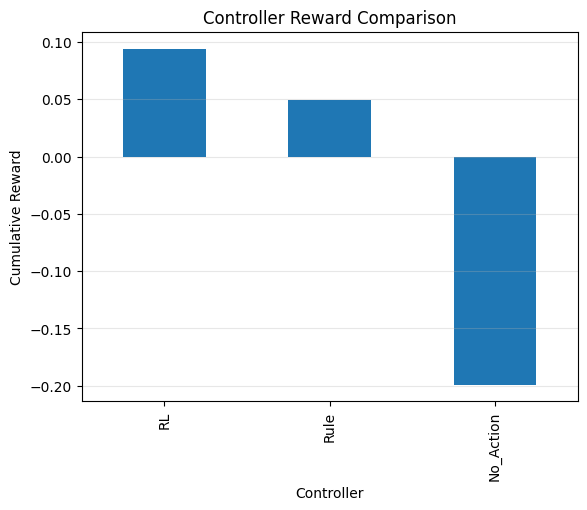

In [19]:
all_rollouts = pd.concat(
    [rl_rollout, rule_rollout, baseline_rollout]
)

reward_summary = (
    all_rollouts
    .groupby("controller")["reward"]
    .mean()
    .sort_values(ascending=False)
)

display(reward_summary)

reward_summary.plot.bar()
plt.xlabel("Controller")
plt.ylabel("Cumulative Reward")
plt.title("Controller Reward Comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Section 9 – Compare productivity trajectories (Which controller preserves productivity?)

Productivity remains one of the most important economic drivers in CHO manufacturing.

This section evaluates how productivity changes over pseudo-time under each controller.

Questions addressed:

- Does RL maintain productivity longer?
- Does RL prevent productivity collapse?
- Does RL outperform traditional process heuristics?

A successful controller should sustain productivity throughout the trajectory rather than achieving only short-term gains.

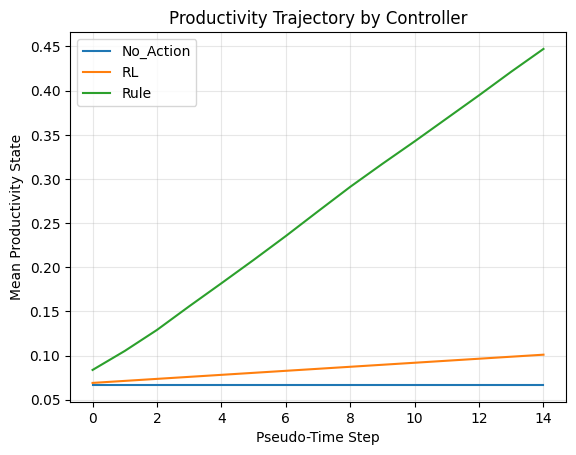

In [15]:
prod_curve = (
    all_rollouts
    .groupby(
        ["controller","pseudo_time"]
    )["productivity_state"]
    .mean()
    .reset_index()
)

for ctrl in prod_curve["controller"].unique():

    tmp = prod_curve[
        prod_curve["controller"]==ctrl
    ]

    plt.plot(
        tmp["pseudo_time"],
        tmp["productivity_state"],
        label=ctrl
    )

plt.legend()
plt.xlabel("Pseudo-Time Step")
plt.ylabel("Mean Productivity State")
plt.title("Productivity Trajectory by Controller")
plt.grid(alpha=0.3)
plt.show()

# Section 10 – Compare burden trajectories (Which controller minimizes burden?)

High-producing clones often experience increasing cellular burden.

Examples include:

- metabolic burden
- oxidative stress
- ER stress
- nutrient limitations

This section evaluates whether a controller can reduce burden accumulation during culture progression.

Lower burden generally indicates:

- improved cellular health
- greater process robustness
- lower risk of culture failure

An effective controller should slow or reverse burden accumulation over time.

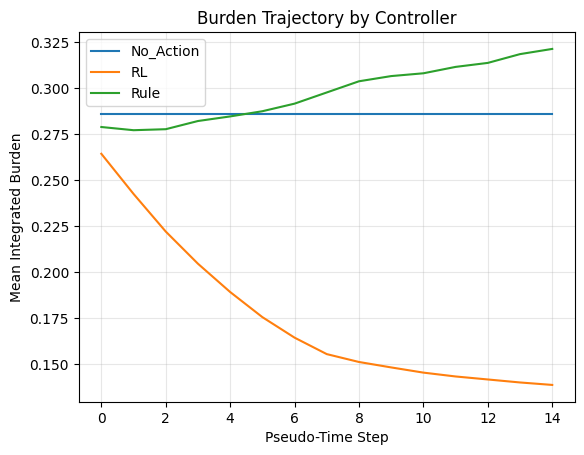

In [17]:
burden_curve = (
    all_rollouts
    .groupby(
        ["controller","pseudo_time"]
    )["integrated_burden"]
    .mean()
    .reset_index()
)

for ctrl in burden_curve["controller"].unique():

    tmp = burden_curve[
        burden_curve["controller"]==ctrl
    ]

    plt.plot(
        tmp["pseudo_time"],
        tmp["integrated_burden"],
        label=ctrl
    )

plt.legend()
plt.xlabel("Pseudo-Time Step")
plt.ylabel("Mean Integrated Burden")
plt.title("Burden Trajectory by Controller")
plt.grid(alpha=0.3)
plt.show()

# Section 11 – Compare quality trajectories (Which controller protects quality?)

High productivity alone is not sufficient for therapeutic protein manufacturing.

Product quality attributes such as:

- galactosylation
- sialylation

must also remain acceptable.

This section compares quality trajectories generated by each controller.

The goal is to determine whether process interventions can improve product quality while maintaining productivity and stability.

Controllers that preserve favorable glycosylation profiles are preferred for manufacturing applications.

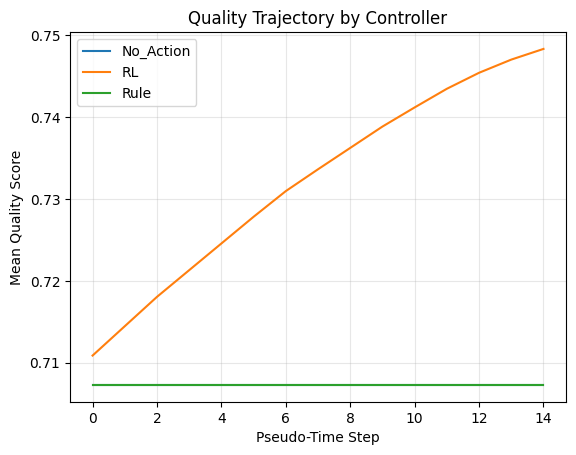

In [18]:
quality_curve = (
    all_rollouts
    .groupby(
        ["controller","pseudo_time"]
    )["galactosylation"]
    .mean()
    .reset_index()
)

for ctrl in quality_curve["controller"].unique():

    tmp = quality_curve[
        quality_curve["controller"]==ctrl
    ]

    plt.plot(
        tmp["pseudo_time"],
        tmp["galactosylation"],
        label=ctrl
    )

plt.legend()
plt.xlabel("Pseudo-Time Step")
plt.ylabel("Mean Quality Score")
plt.title("Quality Trajectory by Controller")
plt.grid(alpha=0.3)
plt.show()

# Section 12 – Policy utilization analysis (How does the controller make decisions?)

A controller's performance depends not only on outcomes but also on how it makes decisions.

This section examines which actions are selected during rollout simulations.

Examples include:

- adaptive feed
- mild temperature shift
- perfusion rescue
- stress mitigation

Understanding action frequency helps reveal:

- controller behavior
- intervention preferences
- process-control strategies

This provides interpretability for the learned RL policy.

action
perfusion_rescue     540
no_action            345
stress_mitigation    210
mild_temp_shift      180
adaptive_feed        105
Name: count, dtype: int64

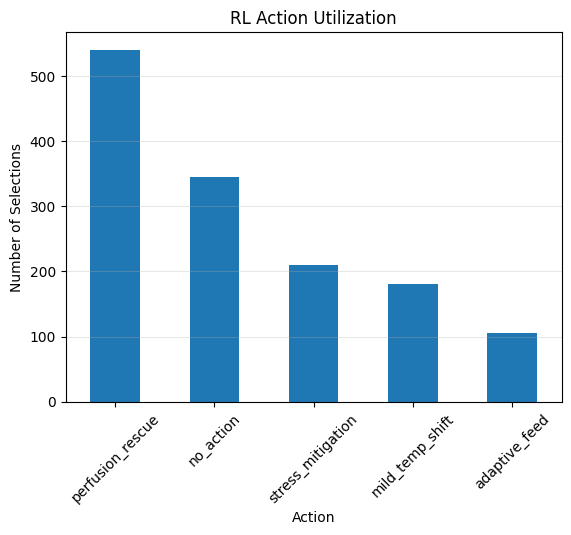

In [20]:
action_usage = (
    rl_rollout["action"]
    .value_counts()
)

display(action_usage)

action_usage.plot.bar()
plt.xlabel("Action")
plt.ylabel("Number of Selections")
plt.title("RL Action Utilization")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Section 13 – Best-Controller Summary (Final winner and deployment candidate)

This section summarizes the performance of all controllers.

Metrics compared include:

- cumulative reward
- productivity
- burden
- quality
- robustness

The objective is to identify which control strategy produces the most favorable overall cellular trajectories.

The winning controller becomes the preferred decision engine for the digital twin and serves as the foundation for future autonomous process optimization.

In [23]:
# --------------------------------------------------
# Section 13 – Best-controller summary
# --------------------------------------------------

controller_summary = (
    all_rollouts
    .groupby("controller")[
        [
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
        ]
    ]
    .mean()
    .round(3)
    .sort_values("reward", ascending=False)
)

display(controller_summary)

,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation
controller,,,,,,
RL,0.094,0.085,0.175,0.171,0.732,0.677
Rule,0.049,0.263,0.298,0.261,0.707,0.661
No_Action,-0.199,0.067,0.286,0.324,0.707,0.661


# Section 13b – Controller Scorecard and Overall Ranking

The controller summary shows individual metrics, but process decisions require a balanced score.

This section converts each controller into an overall score using:

- higher reward = better
- higher productivity = better
- higher galactosylation = better
- higher sialylation = better
- lower burden = better
- lower failure risk = better

The final rank identifies the most balanced controller for deployment inside the digital twin.

,overall_rank,controller,overall_score,reward,productivity_state,integrated_burden,stress_failure_risk,galactosylation,sialylation
0,1,RL,0.818,0.094,0.085,0.175,0.171,0.732,0.677
1,2,Rule,0.495,0.049,0.263,0.298,0.261,0.707,0.661
2,3,No_Action,0.015,-0.199,0.067,0.286,0.324,0.707,0.661


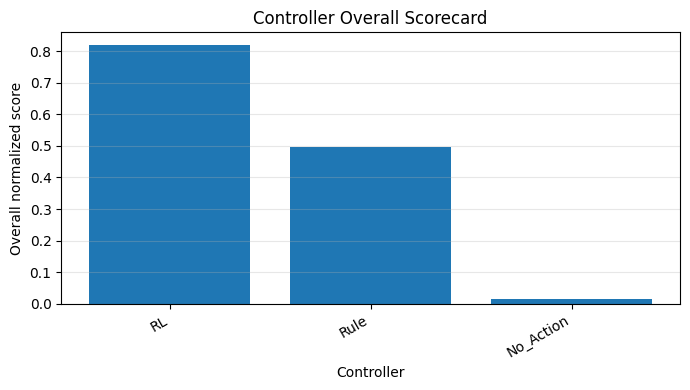

In [24]:
# --------------------------------------------------
# Section 13b – Controller scorecard and overall ranking
# --------------------------------------------------

scorecard = controller_summary.copy().reset_index()

# Normalize helper
def minmax(series):
    return (
        (series - series.min())
        / (series.max() - series.min() + 1e-12)
    )

scorecard["reward_score"] = minmax(scorecard["reward"])
scorecard["productivity_score"] = minmax(scorecard["productivity_state"])
scorecard["galactosylation_score"] = minmax(scorecard["galactosylation"])
scorecard["sialylation_score"] = minmax(scorecard["sialylation"])

# Lower is better for burden and risk, so invert after normalization
scorecard["burden_score"] = 1 - minmax(scorecard["integrated_burden"])
scorecard["risk_score"] = 1 - minmax(scorecard["stress_failure_risk"])

scorecard["overall_score"] = (
    0.30 * scorecard["reward_score"]
    + 0.20 * scorecard["productivity_score"]
    + 0.15 * scorecard["galactosylation_score"]
    + 0.10 * scorecard["sialylation_score"]
    + 0.15 * scorecard["burden_score"]
    + 0.10 * scorecard["risk_score"]
)

scorecard["overall_rank"] = (
    scorecard["overall_score"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

scorecard = (
    scorecard
    .sort_values(["overall_rank", "overall_score"])
    .reset_index(drop=True)
)

display(
    scorecard[
        [
            "overall_rank",
            "controller",
            "overall_score",
            "reward",
            "productivity_state",
            "integrated_burden",
            "stress_failure_risk",
            "galactosylation",
            "sialylation",
        ]
    ].round(3)
)

plt.figure(figsize=(7, 4))
plt.bar(scorecard["controller"], scorecard["overall_score"])
plt.xlabel("Controller")
plt.ylabel("Overall normalized score")
plt.title("Controller Overall Scorecard")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Section 14 – Export results

In [14]:
OUT = (
    ROOT /
    "data" /
    "synthetic" /
    "digital_twin"
)

all_rollouts.to_csv(
    OUT /
    "notebook16_rollout_trajectories_5000_legacy.csv",
    index=False
)

controller_summary.to_csv(
    OUT /
    "notebook16_controller_summary_5000_legacy.csv"
)

print("Notebook16 export complete")

Notebook16 export complete


# Notebook16 Summary

Notebook16 evaluated whether the learned RL policy can actively control the CHO digital twin.

Major achievements:

- executed RL-guided rollouts
- compared RL vs rule-based vs no-action controllers
- quantified cumulative reward
- tracked productivity trajectories
- tracked burden trajectories
- tracked glycan quality trajectories
- characterized RL action utilization

This notebook represents the first active decision-making evaluation within the CHO digital twin framework.

The output establishes whether learned policies can outperform static intervention strategies.

The next logical step is:

Notebook17

Executive Clone Screening and Production Candidate Ranking

which reconnects the digital twin platform back to the original CLD objective:

selecting the best production candidates as early as possible.

# References

## Reinforcement Learning

1. Sutton RS, Barto AG.

   Reinforcement Learning: An Introduction (2nd Edition).

   MIT Press, 2018.

   ISBN: 9780262039246

   https://www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf

---

2. Watkins CJCH, Dayan P.

   Q-Learning.

   Machine Learning (1992)

   Volume 8, Pages 279–292.

   DOI:
   10.1007/BF00992698

---

## Offline Reinforcement Learning

3. Levine S, Kumar A, Tucker G, Fu J.

   Offline Reinforcement Learning:
   Tutorial, Review and Perspectives on Open Problems.

   arXiv:2005.01643

   DOI:
   10.48550/arXiv.2005.01643

---

## Digital Twins

4. Tao F, Zhang H, Liu A, Nee AYC.

   Digital Twin in Industry:
   State-of-the-Art.

   IEEE Transactions on Industrial Informatics (2019)

   DOI:
   10.1109/TII.2018.2873186

---

## Process Analytical Technology

5. FDA.

   Guidance for Industry:
   PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing and Quality Assurance.

   U.S. Food and Drug Administration (2004)

   https://www.fda.gov

---

## CHO Systems Biology

6. Clarke C, Doolan P, Barron N, Meleady P.

   Predicting Cell-Specific Productivity from CHO Cell Omics.

   Biotechnology Journal (2011)

   DOI:
   10.1002/biot.201000397

---

7. Gutierrez JM, Lewis NE.

   Optimizing CHO Cell Metabolism for Bioprocessing.

   Current Opinion in Biotechnology (2015)

   DOI:
   10.1016/j.copbio.2014.12.007

---

## Multi-Omics

8. Hasin Y, Seldin M, Lusis A.

   Multi-omics Approaches to Disease.

   Genome Biology (2017)

   DOI:
   10.1186/s13059-017-1215-1

---

## Glycosylation Engineering

9. Lalonde ME, Durocher Y.

   Therapeutic Glycoprotein Production in Mammalian Cells.

   Journal of Biotechnology (2017)

   DOI:
   10.1016/j.jbiotec.2017.05.028

---

## CHO Cell Engineering

10. Feary M, Bracewell DG.

    The Challenge of CHO Cell Engineering.

    Biotechnology Letters (2022)

    DOI:
    10.1007/s10529-022-03252-7